# Analyse bivariée de variables qualitatives et test du chi-2
Ici est présenté une analyse bivariée de variables qualitatives dans le but d'analyser la relation entre le lieu d'origine, l'année de naissance, ainsi que le genre des individus de la population d'étude.
Nous procéderons à un test du chi-2 afin de déterminer s'il existe une association statistiquement significative entre les différentes variables dans le temps.
De cette manière, nous tentons d'observer de quelle manière la distribution géogrpahique de la population évolue dans le temps et s'il y a une sur-représentation de femmes sociologues dans certaines régions.

In [1]:
import pandas as pd
import scipy.stats as stats
import statsmodels.api as sm

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import numpy as np
import seaborn as sns

In [2]:
import pprint
import csv
import sys

import time
import datetime
from dateutil import parser
from shutil import copyfile

In [3]:
import warnings
warnings.filterwarnings('ignore')

# Création d'une dataframe à partir des données à analyser
Nous utiliserons ici les données produites précédemment dans la page da2, càd une liste des individus avec leur années de naissance, leur genre, leur lieu de naissance, ainsi qu'à quelle région du monde leur lieu naissance correspond.

In [4]:
csv_address='data_analysis/da3-birthYear-gender-region.csv'
df_p = pd.read_csv(csv_address)
df_p.head()

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,FID,REGION
0,http://www.wikidata.org/entity/Q1685927,Jean-Guillaume-César-Alexandre-Hippolyte Colins,1783,male,Brussels metropolitan area,POINT (4.3525 50.846667),http://www.wikidata.org/entity/Q9005,1781-1790,22,Western Europe
1,http://www.wikidata.org/entity/Q20012,Adolphe Quetelet,1796,male,Ghent,POINT (3.725278 51.053611),http://www.wikidata.org/entity/Q1296,1791-1800,22,Western Europe
2,http://www.wikidata.org/entity/Q1708975,José Antonio Saco,1797,male,Bayamo,POINT (-76.642778 20.381667),http://www.wikidata.org/entity/Q115382,1791-1800,3,Caribbean
3,http://www.wikidata.org/entity/Q973094,Ramón de la Sagra,1798,male,A Coruña,POINT (-8.400027 43.373857),http://www.wikidata.org/entity/Q8757,1791-1800,19,Southern Europe
4,http://www.wikidata.org/entity/Q957065,Henry Charles Carey,1793,male,Philadelphia,POINT (-75.163611 39.952778),http://www.wikidata.org/entity/Q1345,1791-1800,23,Northern America


In [5]:
### Inspect the dataframe and 
# notably if there are missing values
df_p.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9912 entries, 0 to 9911
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   uriPer      9912 non-null   object
 1   labelPer    9646 non-null   object
 2   birthYear   9912 non-null   int64 
 3   gender      9873 non-null   object
 4   labelPlace  9912 non-null   object
 5   geometry    9912 non-null   object
 6   uriPlace    9912 non-null   object
 7   periods     9494 non-null   object
 8   FID         9912 non-null   int64 
 9   REGION      9912 non-null   object
dtypes: int64(2), object(8)
memory usage: 774.5+ KB


# Distribution des lieux de naissance

In [6]:
### Group and count
# We observe some dispersion that requires grouping the categories of the variable
df_region = df_p.groupby('REGION').size()
df_region = pd.DataFrame(df_region.sort_values(ascending = False))
#df_contCode.reset_index(inplace=True)
df_region.columns=['number']
print(df_region)

                       number
REGION                       
Western Europe           2865
Eastern Europe           1880
Southern Europe          1336
Northern America         1021
South America             678
Northern Europe           498
Eastern Asia              474
European Russia           282
Western Asia              202
Southern Asia             155
Northern Africa           112
Central America           108
Asiatic Russia             50
Australia/New Zealand      49
Western Africa             45
Caribbean                  44
Southeastern Asia          34
Middle Africa              24
Southern Africa            21
Central Asia               20
Eastern Africa             14


In [7]:
### We define a function that codes and aggregates the values in order to avoid dispersion, 
# which would make them difficult to analyse.

def codeRegion(region: str):
    if ' Africa' in region:
        output='Africa'
    elif 'Russia' in region:
        output='Russia'
    elif 'Asia' in region:
        output='Asia'
    elif 'Austral' in region \
        or 'Polyn' in region \
        or 'Micron' in region:
        output='Australia/Ilands'
    elif 'Northern America' in region:
        output='America North'
    elif ' America' in region:
        output='America Central/South'
    elif 'Caribb' in region:
        output='America Central/South'
    else:
        output=region
    return output

In [8]:
### Test the function
# r='Southern Africa'
# r='Central Asia'
r='Asiatic Russia'
codeRegion(r)

'Russia'

In [9]:
### Create a new column with the coded values
df_p['coded_region']=df_p.REGION.apply(lambda x : codeRegion(x))

In [10]:
### Group and count
df_region = df_p.groupby('coded_region').size()
df_region = pd.DataFrame(df_region.sort_values(ascending = False))
#df_contCode.reset_index(inplace=True)
df_region.columns=['number']
print(df_region)

                       number
coded_region                 
Western Europe           2865
Eastern Europe           1880
Southern Europe          1336
America North            1021
Asia                      885
America Central/South     830
Northern Europe           498
Russia                    332
Africa                    216
Australia/Ilands           49


In [12]:
### Add frequencies to the counts aof a variable's categories

df_region['frequency'] = (100 * df_region['number'] \
                                   / df_region['number'].sum()).round(2)
df_region

,number,frequency
coded_region,,
Western Europe,2865,28.90
Eastern Europe,1880,18.97
Southern Europe,1336,13.48
America North,1021,10.30
Asia,885,8.93
America Central/South,830,8.37
Northern Europe,498,5.02
Russia,332,3.35
Africa,216,2.18


In [13]:
### Transform to one row dataframe
ljt = pd.DataFrame(df_region['frequency'].sort_values(ascending=False)).T
ljt

coded_region,Western Europe,Eastern Europe,Southern Europe,America North,Asia,America Central/South,Northern Europe,Russia,Africa,Australia/Ilands
frequency,28.9,18.97,13.48,10.3,8.93,8.37,5.02,3.35,2.18,0.49


In [14]:
### Create color palette
colors = plt.cm.tab20(range(10))
print(colors[:2], '\n', colors[-2:])

[[0.12156863 0.46666667 0.70588235 1.        ]
 [0.68235294 0.78039216 0.90980392 1.        ]] 
 [[0.58039216 0.40392157 0.74117647 1.        ]
 [0.77254902 0.69019608 0.83529412 1.        ]]


In [15]:
### Reverse the list
rev_col=colors[::-1]
print(rev_col[:2], '\n', rev_col[-2:])

[[0.77254902 0.69019608 0.83529412 1.        ]
 [0.58039216 0.40392157 0.74117647 1.        ]] 
 [[0.68235294 0.78039216 0.90980392 1.        ]
 [0.12156863 0.46666667 0.70588235 1.        ]]


[]

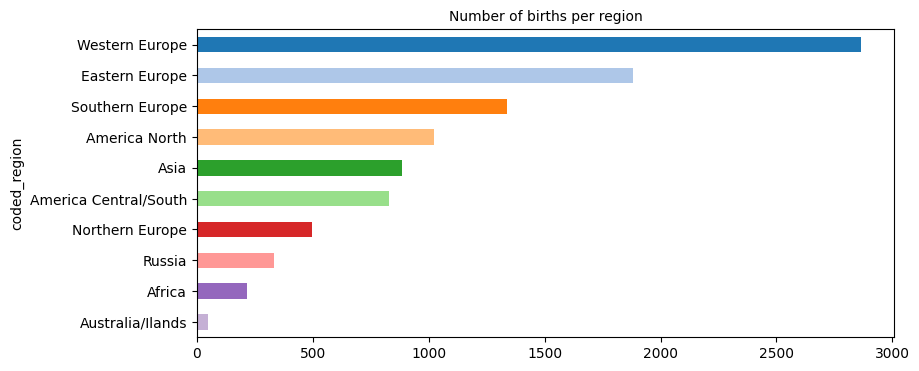

In [16]:
## Distribution of births per region
fig = df_region.number.sort_values().plot(kind='barh', figsize=(9,4), color=rev_col, width=0.5)
fig.set_title('Number of births per region', size=10)
plt.plot()

Nous pouvons déjà observer une répartition assez inégale des lieux de naissance des sociologues puisque la très grande majorité semble être née en Europe.

[]

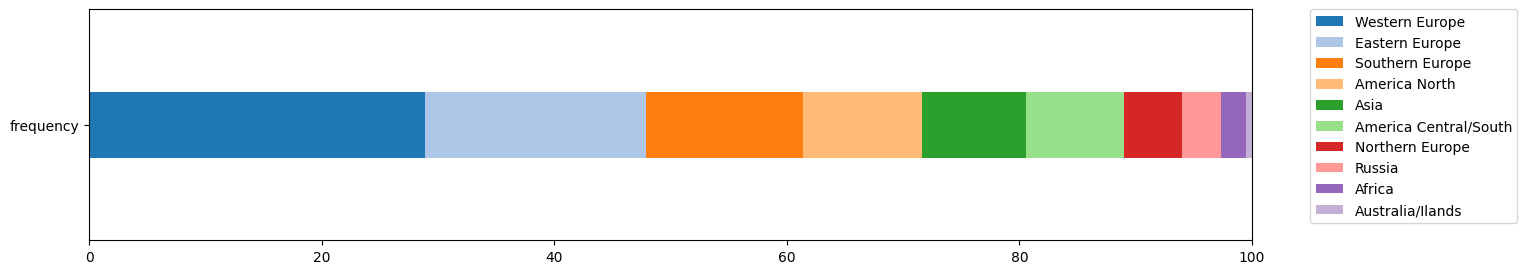

In [17]:
### Pandas plot reference
# https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.plot.html
## Barplots
# https://www.shanelynn.ie/bar-plots-in-python-using-pandas-dataframes/

fig = ljt.plot(kind='barh', stacked=True, figsize=(15,3), color=colors, width=0.2, xlim=[0,100])
fig.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
fig.plot()

Ce fait en encore plus frappant sous cette forme puisque l'on peut voir que plus de 60% des sociologues sont né.e.s en Europe.

# Transformation des années de naissance en périodes d'activité professionnelle

In [18]:
### Create imputed activity year
df_p['activityYear'] = df_p.birthYear.apply(lambda x : int(x)+45)

In [19]:
### Create list of 25 years periods

yr = df_p.activityYear

l_25 = list(range(min(yr), max(yr)+26, 25))
print(l_25[:5],l_25[-5:], len(l_25)-1)

[1828, 1853, 1878, 1903, 1928] [1953, 1978, 2003, 2028, 2053] 9


In [20]:
### fonction pd.cut : https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.cut.html
# A new column is added containing the period, based on the previous list and the year value

df_p['per_25'] = pd.cut(df_p['activityYear'], l_25, right=False)

### Rewrite the added code to make it more readable
df_p['per_25'] = df_p['per_25'].apply(lambda x : str(int(x.left))+'-'+ str(int(x.right)-1))

# Inspection
df_p.head(3)

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,FID,REGION,coded_region,activityYear,per_25
0,http://www.wikidata.org/entity/Q1685927,Jean-Guillaume-César-Alexandre-Hippolyte Colins,1783,male,Brussels metropolitan area,POINT (4.3525 50.846667),http://www.wikidata.org/entity/Q9005,1781-1790,22,Western Europe,Western Europe,1828,1828-1852
1,http://www.wikidata.org/entity/Q20012,Adolphe Quetelet,1796,male,Ghent,POINT (3.725278 51.053611),http://www.wikidata.org/entity/Q1296,1791-1800,22,Western Europe,Western Europe,1841,1828-1852
2,http://www.wikidata.org/entity/Q1708975,José Antonio Saco,1797,male,Bayamo,POINT (-76.642778 20.381667),http://www.wikidata.org/entity/Q115382,1791-1800,3,Caribbean,America Central/South,1842,1828-1852


In [21]:
### Distribution of activities by 25 years periods
activities_per = pd.DataFrame(df_p.groupby(by='per_25').size())
activities_per.columns=['number']
print(activities_per)

           number
per_25           
1828-1852      17
1853-1877      52
1878-1902     148
1903-1927     373
1928-1952     668
1953-1977    1628
1978-2002    4204
2003-2027    2529
2028-2052     293


In [22]:
### Add frequency

activities_per['frequency'] = (100 * activities_per['number'] \
                                   / activities_per['number'].sum()).round(2)
activities_per

,number,frequency
per_25,,
1828-1852,17,0.17
1853-1877,52,0.52
1878-1902,148,1.49
1903-1927,373,3.76
1928-1952,668,6.74
1953-1977,1628,16.42
1978-2002,4204,42.41
2003-2027,2529,25.51
2028-2052,293,2.96


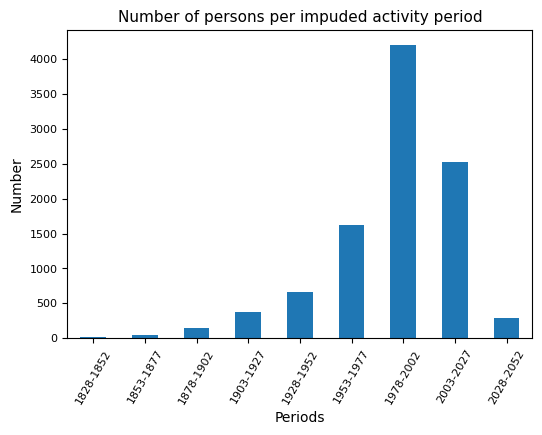

In [23]:
### Distribution by impuded active generations
ax = activities_per.number.plot(kind='bar',rot=60, fontsize=8, figsize=(6,4))
plt.ylabel('Number')
plt.xlabel('Periods')
plt.title('Number of persons per impuded activity period', size=11)
plt.show()

Avec ce graphique on peut voir que la sociologie à vraiment connu un essor entre 1978 et 2002 qui a ensuite nettement baissé, même se les effectifs restent importants.

In [24]:
### Transform to a one row dataframe
ljt = pd.DataFrame(activities_per.frequency.sort_index(ascending=True)).T
ljt

per_25,1828-1852,1853-1877,1878-1902,1903-1927,1928-1952,1953-1977,1978-2002,2003-2027,2028-2052
frequency,0.17,0.52,1.49,3.76,6.74,16.42,42.41,25.51,2.96


In [25]:
### Map the intensity of the colours to the frequency

frequencies = activities_per.frequency.sort_index(ascending=True)

# Normalize frequencies to 0-1 range for colormap mapping
norm = mcolors.Normalize(vmin=frequencies.min(), vmax=frequencies.max())

# Create a list of colors based on the 'Blues' colormap
# Higher frequencies get darker blues
colors = [plt.cm.Blues(norm(freq)) for freq in frequencies]

[]

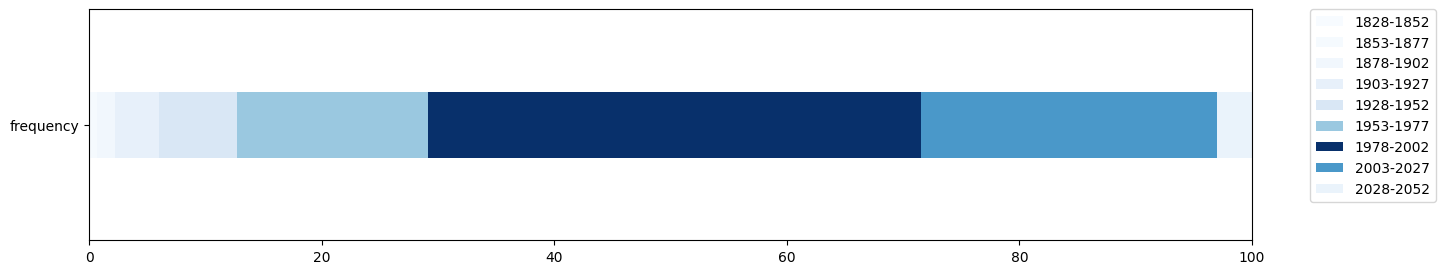

In [26]:
### Frequencies of periods. Total = 100%

fig = ljt.plot(kind='barh', stacked=True, figsize=(15,3), color=colors, width=0.2, xlim=[0,100])
fig.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
fig.plot()

On retrouve les mêmes informations que précédemment mais fractionnées en pourcentages ce qui nous permet de voir que près de 40% des sociologues ont exercé ce métier entre 1978 et 2002.

# Analyse bivariée
- Un tableau de contingences organise les données pour montrer la fréquence de deux (ou plus) variables qualitatives arrangées en lignes et colonnes, révélant les relations éventuelles qui existent entre elles.
- Les taux de fréquences sont produits en calculant à quel fréquences chaque combinaison apparait dans les données utilisées.

In [27]:
### Contingency table: 
# count how many individuals exhibit both of these categories for each of the two variables 
per_vs_region=pd.crosstab(df_p.per_25, df_p.coded_region, margins=True)
per_vs_region

coded_region,Africa,America Central/South,America North,Asia,Australia/Ilands,Eastern Europe,Northern Europe,Russia,Southern Europe,Western Europe,All
per_25,,,,,,,,,,,
1828-1852,0,1,2,0,0,1,1,1,1,10,17
1853-1877,0,1,3,0,0,5,7,7,5,24,52
1878-1902,1,12,12,2,0,28,8,12,26,47,148
1903-1927,1,17,69,11,1,94,25,5,46,104,373
1928-1952,4,42,123,52,2,149,19,24,41,212,668
1953-1977,28,100,294,136,3,371,79,53,138,426,1628
1978-2002,133,404,408,392,24,690,248,146,555,1204,4204
2003-2027,45,221,100,273,17,469,99,78,472,755,2529
2028-2052,4,32,10,19,2,73,12,6,52,83,293


In [28]:
### If needed, you could restrict to a minimal count and having thus 
# all the periods but with less regions
X_reg_all_period = per_vs_region.loc[:, per_vs_region.iloc[-1] > 500].iloc[:-1, :-1 ]
X_reg_all_period

coded_region,America Central/South,America North,Asia,Eastern Europe,Southern Europe,Western Europe
per_25,,,,,,
1828-1852,1,2,0,1,1,10
1853-1877,1,3,0,5,5,24
1878-1902,12,12,2,28,26,47
1903-1927,17,69,11,94,46,104
1928-1952,42,123,52,149,41,212
1953-1977,100,294,136,371,138,426
1978-2002,404,408,392,690,555,1204
2003-2027,221,100,273,469,472,755
2028-2052,32,10,19,73,52,83


In [29]:
### But we keep here all the information
X_reg_all_period = per_vs_region.iloc[:-1, :-1 ]
X_reg_all_period

coded_region,Africa,America Central/South,America North,Asia,Australia/Ilands,Eastern Europe,Northern Europe,Russia,Southern Europe,Western Europe
per_25,,,,,,,,,,
1828-1852,0,1,2,0,0,1,1,1,1,10
1853-1877,0,1,3,0,0,5,7,7,5,24
1878-1902,1,12,12,2,0,28,8,12,26,47
1903-1927,1,17,69,11,1,94,25,5,46,104
1928-1952,4,42,123,52,2,149,19,24,41,212
1953-1977,28,100,294,136,3,371,79,53,138,426
1978-2002,133,404,408,392,24,690,248,146,555,1204
2003-2027,45,221,100,273,17,469,99,78,472,755
2028-2052,4,32,10,19,2,73,12,6,52,83


# Test du chi-2 d'indépendance de variables qualitatives

In [30]:
### Calculation of parameters for the chi-square test
statistic, p, dof, expected = stats.chi2_contingency(X_reg_all_period)

In [31]:
### Expected values under independent sampling (H0 hypotheses)

## For the chi-square test the min value in each cell of the expected values should be 5

dfe = pd.DataFrame(expected).round(1)
dfe.index = X_reg_all_period.index
dfe.columns = X_reg_all_period.columns
dfe

coded_region,Africa,America Central/South,America North,Asia,Australia/Ilands,Eastern Europe,Northern Europe,Russia,Southern Europe,Western Europe
per_25,,,,,,,,,,
1828-1852,0.4,1.4,1.8,1.5,0.1,3.2,0.9,0.6,2.3,4.9
1853-1877,1.1,4.4,5.4,4.6,0.3,9.9,2.6,1.7,7.0,15.0
1878-1902,3.2,12.4,15.2,13.2,0.7,28.1,7.4,5.0,19.9,42.8
1903-1927,8.1,31.2,38.4,33.3,1.8,70.7,18.7,12.5,50.3,107.8
1928-1952,14.6,55.9,68.8,59.6,3.3,126.7,33.6,22.4,90.0,193.1
1953-1977,35.5,136.3,167.7,145.4,8.0,308.8,81.8,54.5,219.4,470.6
1978-2002,91.6,352.0,433.0,375.4,20.8,797.4,211.2,140.8,566.6,1215.1
2003-2027,55.1,211.8,260.5,225.8,12.5,479.7,127.1,84.7,340.9,731.0
2028-2052,6.4,24.5,30.2,26.2,1.4,55.6,14.7,9.8,39.5,84.7


In [32]:
## Degrees of freedom and Chi-square

print('Degrees of freedom:', dof, '; Chi-square value:', statistic.round(2))

Degrees of freedom: 72 ; Chi-square value: 646.19


# Distribution des probabilités du chi-2 par rapport aux degrés de liberté

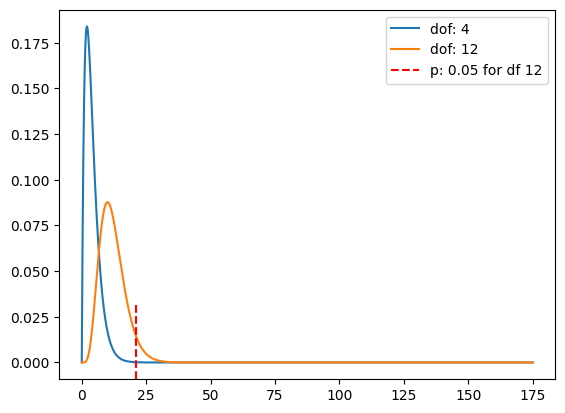

In [33]:
### Documentation ! 
## https://www.statology.org/plot-chi-square-distribution-python/
# x-axis ranges from 0 to 1750 with .001 steps
x = np.arange(0, 175, 0.001)

### plot Chi-square distribution with 4 degrees of freedom
# cf. https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.chi2.html
plt.plot(x, stats.chi2.pdf(x, df=4), label='dof: 4')
plt.plot(x, stats.chi2.pdf(x, df=12), label='dof: 12')

plt.axvline(x=21.026, ymax=0.2, color='red', linestyle='--', label='p: 0.05 for df 12')

plt.legend()
plt.show()

# Test statistique : rejet de l'hypothèse nulle ou indépendance ?
Ici H0 (hypothèse nulle) est que les variables sont indépendantes.

In [34]:
## Degrees of freedom and Chi-square

print('Degrees of freedom:', dof, '; Chi-square value:', statistic.round(2))

Degrees of freedom: 72 ; Chi-square value: 646.19


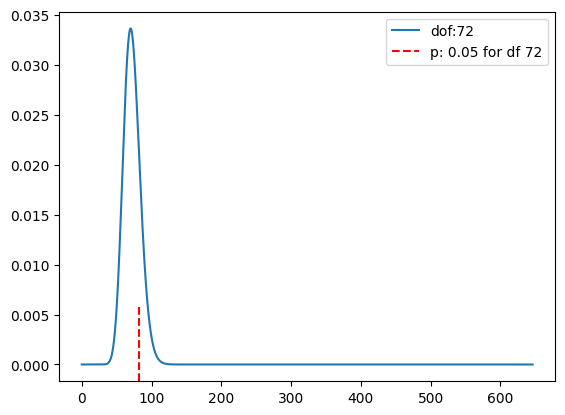

In [35]:
### Applied to our case
x = np.arange(0, statistic, 0.001)

### plot Chi-square distribution with 63 degrees of freedom
plt.plot(x, stats.chi2.pdf(x, df=dof), label='dof:'+ str(dof) )

plt.axvline(x=82.529, ymax=0.2, color='red', linestyle='--', label='p: 0.05 for df ' + str(dof))

plt.legend()
plt.show()

In [65]:
### P-value
print('p-value :', p)

p-value : 5.128605807097078e-100


Le test de chi-2 n'est pas significatif, nous ne pouvons donc pas rejeter H0. Vraisemblablement, les variables sont indépendantes.

# V de Cramer

In [38]:
## Cramer's V with all calculation steps to demonstrate normalization

# 1. Total sample size (n)
n = per_vs_region.iloc[-1, -1]
# print(n)

# 2. Get the dimensions of the table
r, c = X_reg_all_period.shape

# 3. Calculate the correct denominator: min(rows-1, columns-1)
# Note: The returned ‘dof’ is (r-1)*(c-1); this is not directly the divisor for Cramer's rule
k = min(r - 1, c - 1)
# print(k)

# Avoid dividing by zero if the table is 1x1
if k == 0:
    cramers_v = 0
else:
    # 4. Apply the formula
    cramers_v = np.sqrt(statistic / (n * k))

print(f"Cramer's V : {cramers_v.round(5)}")

Cramer's V : 0.09027


In [39]:
### Cramér's V (normalized phi) coefficient
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.contingency.association.html
vc = stats.contingency.association(X_reg_all_period, method='cramer')
print('Cramèr\'s V:', vc)

Cramèr's V: 0.09027212952406222


Le V de Cramèr ne nous apprend rien de neuf si ce n'est que pas variables sont très faiblement associées.

In [40]:
# 2. Calculate Adjusted Residuals
observed = X_reg_all_period
row_totals = observed.sum(axis=1).values.reshape(-1, 1)
print(row_totals)
col_totals = observed.sum(axis=0).values.reshape(1, -1)
print(col_totals)
n = observed.sum().sum()

[[  17]
 [  52]
 [ 148]
 [ 373]
 [ 668]
 [1628]
 [4204]
 [2529]
 [ 293]]
[[ 216  830 1021  885   49 1880  498  332 1336 2865]]


In [41]:
# Basic formula
residuals = (round((observed-expected)/np.sqrt(expected),2))
residuals.round(1)

coded_region,Africa,America Central/South,America North,Asia,Australia/Ilands,Eastern Europe,Northern Europe,Russia,Southern Europe,Western Europe
per_25,,,,,,,,,,
1828-1852,-0.6,-0.4,0.2,-1.2,-0.3,-1.2,0.2,0.6,-0.8,2.3
1853-1877,-1.1,-1.6,-1.0,-2.2,-0.5,-1.6,2.7,4.0,-0.8,2.3
1878-1902,-1.2,-0.1,-0.8,-3.1,-0.9,-0.0,0.2,3.2,1.4,0.6
1903-1927,-2.5,-2.6,4.9,-3.9,-0.6,2.8,1.4,-2.1,-0.6,-0.4
1928-1952,-2.8,-1.9,6.5,-1.0,-0.7,2.0,-2.5,0.3,-5.2,1.4
1953-1977,-1.3,-3.1,9.8,-0.8,-1.8,3.5,-0.3,-0.2,-5.5,-2.0
1978-2002,4.3,2.8,-1.2,0.9,0.7,-3.8,2.5,0.4,-0.5,-0.3
2003-2027,-1.4,0.6,-9.9,3.1,1.3,-0.5,-2.5,-0.7,7.1,0.9
2028-2052,-0.9,1.5,-3.7,-1.4,0.5,2.3,-0.7,-1.2,2.0,-0.2


In [42]:
# Formula for Adjusted Residuals
adjusted_resids = (observed - expected) / np.sqrt(expected * (1 - row_totals/n) * (1 - col_totals/n))
adjusted_resids.round(1)

coded_region,Africa,America Central/South,America North,Asia,Australia/Ilands,Eastern Europe,Northern Europe,Russia,Southern Europe,Western Europe
per_25,,,,,,,,,,
1828-1852,-0.6,-0.4,0.2,-1.3,-0.3,-1.4,0.2,0.6,-0.9,2.7
1853-1877,-1.1,-1.7,-1.1,-2.3,-0.5,-1.7,2.8,4.1,-0.8,2.8
1878-1902,-1.3,-0.1,-0.9,-3.3,-0.9,-0.0,0.2,3.2,1.5,0.8
1903-1927,-2.6,-2.7,5.3,-4.1,-0.6,3.1,1.5,-2.2,-0.7,-0.4
1928-1952,-2.9,-2.0,7.1,-1.1,-0.7,2.3,-2.7,0.4,-5.8,1.7
1953-1977,-1.4,-3.6,11.3,-0.9,-2.0,4.3,-0.3,-0.2,-6.5,-2.7
1978-2002,5.8,3.8,-1.7,1.2,0.9,-5.6,3.4,0.6,-0.7,-0.5
2003-2027,-1.6,0.8,-12.2,3.8,1.5,-0.6,-3.0,-0.9,8.8,1.2
2028-2052,-1.0,1.6,-3.9,-1.5,0.5,2.6,-0.7,-1.3,2.2,-0.2


In [43]:
### Using statmodels (sm)

# 1. Create the Table object directly from your data
table = sm.stats.Table(X_reg_all_period)

# 2. Get Adjusted Residuals instantly (no manual formula needed)
adjusted_resids = table.standardized_resids
adjusted_resids.round(1)

coded_region,Africa,America Central/South,America North,Asia,Australia/Ilands,Eastern Europe,Northern Europe,Russia,Southern Europe,Western Europe
per_25,,,,,,,,,,
1828-1852,0.2,-0.5,0.1,-0.9,1.3,-1.5,0.1,0.5,-1.0,2.4
1853-1877,-0.6,-1.7,-1.1,-2.1,0.4,-1.8,2.7,4.0,-0.9,2.6
1878-1902,-1.3,-0.1,-0.9,-3.3,-0.3,-0.0,0.2,3.2,1.5,0.7
1903-1927,-2.6,-2.7,5.3,-4.1,-0.7,3.1,1.5,-2.2,-0.7,-0.4
1928-1952,-2.9,-2.0,7.1,-1.1,-0.8,2.3,-2.7,0.4,-5.8,1.7
1953-1977,-1.4,-3.6,11.3,-0.9,-2.0,4.3,-0.3,-0.2,-6.5,-2.7
1978-2002,5.7,3.8,-1.7,1.2,0.7,-5.6,3.4,0.6,-0.7,-0.5
2003-2027,-1.6,0.8,-12.2,3.8,1.3,-0.6,-3.0,-0.9,8.9,1.2
2028-2052,-1.0,1.6,-3.9,-1.5,0.4,2.6,-0.7,-1.3,2.2,-0.2


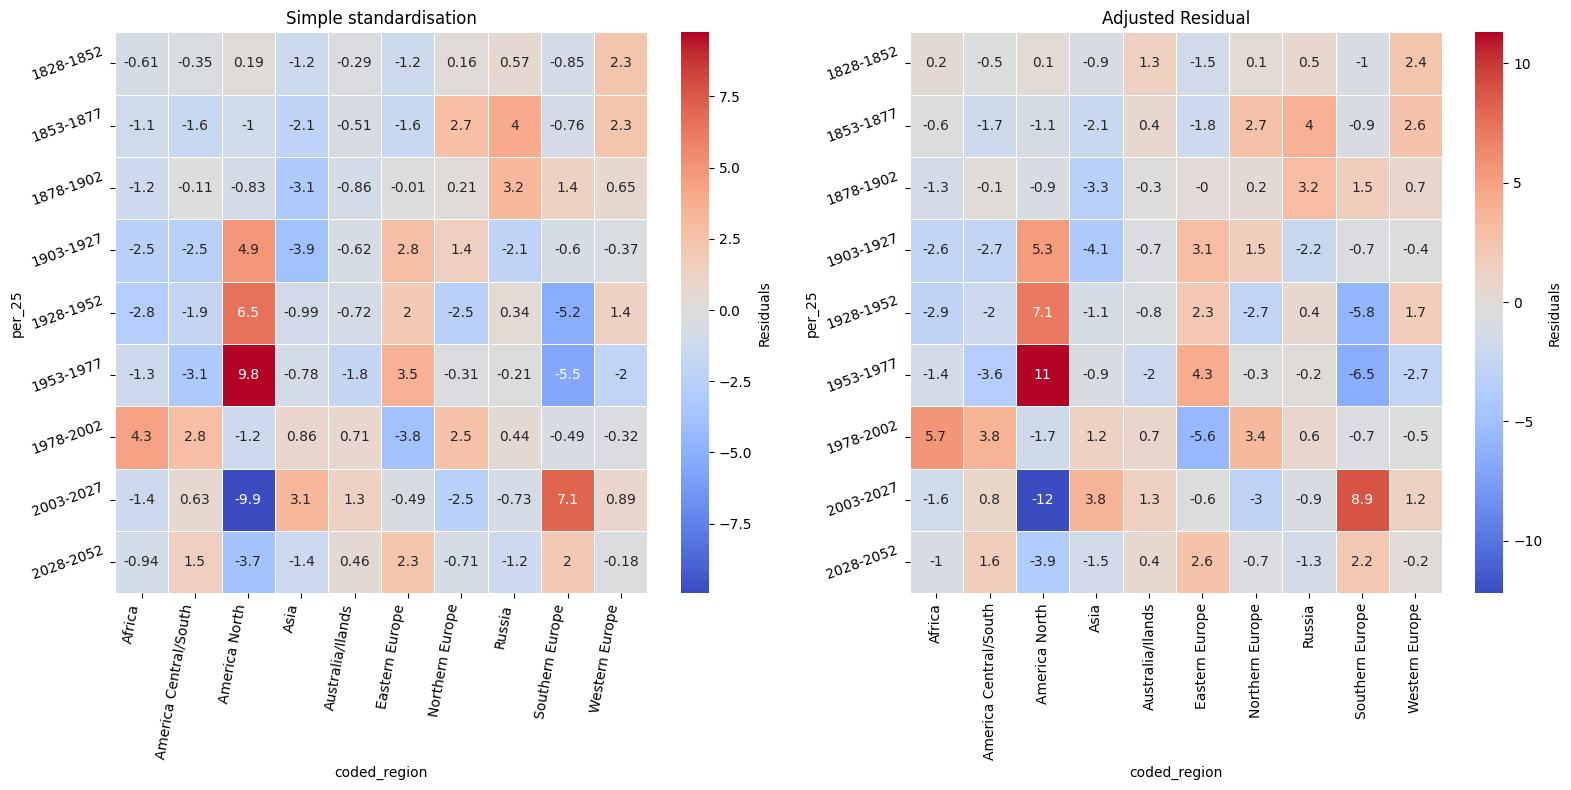

In [44]:
### Compare the two methods of calculation of residuals

# 3. Plot
fig, ax = plt.subplots(1,2,figsize=(16,8))         

# Create heatmap
sns.heatmap(
    residuals, 
    annot=True,            # Use boolean True to annotate with data values
    cmap="coolwarm", 
    linewidths=.5, 
    ax=ax[0],
    cbar_kws={'label': 'Residuals'}
)
# 3. Fix Label Rotation (Safe Method)
# This rotates existing ticks without risking a count mismatch
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=80, ha='right')
ax[0].set_yticklabels(ax[0].get_yticklabels(), rotation=20, va='center')
ax[0].set_title("Simple standardisation", fontsize=12)


# Create heatmap
sns.heatmap(
    adjusted_resids.round(1), 
    annot=True,            # Use boolean True to annotate with data values
    cmap="coolwarm", 
    linewidths=.5, 
    ax=ax[1],
    cbar_kws={'label': 'Residuals'}
)
# 3. Fix Label Rotation (Safe Method)
# This rotates existing ticks without risking a count mismatch
#ax.set_xticklabels(ax.get_xticklabels(), rotation=80, ha='right')
ax[1].set_yticklabels(ax[1].get_yticklabels(), rotation=20, va='center')
ax[1].set_title("Adjusted Residual", fontsize=12)

# ax.set_title("Heatmap of Adjusted Residuals (via statsmodels)")
plt.tight_layout()
plt.show()

On constate dans les deux cas très peu de variations. On peut tout de même obersvé dans le premier comme dans le deuxième tableau quelques tendances. Il y a par exemple un nombre significativement supérieur à la moyenne de sociologues en Amérique du Nord entre 1953 et 1977. Chose qui entre 2003 et 2027 change drastiquement puisque le nombre de sociologues chute et c'est plutôt l'Europe du Sud qui se distingue.

# Analyse bivariée des genres

In [45]:
## filter to only retain statistically significant categories, 
# given the obeserved distribution
df_pg = df_p[df_p['gender'].isin(['female', 'male'])]

In [46]:
gender_vs_region=pd.crosstab(df_pg.gender, df_pg.coded_region, margins=True)
gender_vs_region

coded_region,Africa,America Central/South,America North,Asia,Australia/Ilands,Eastern Europe,Northern Europe,Russia,Southern Europe,Western Europe,All
gender,,,,,,,,,,,
female,55,297,229,175,17,457,131,69,348,652,2430
male,161,529,787,686,27,1423,365,262,981,2209,7430
All,216,826,1016,861,44,1880,496,331,1329,2861,9860


In [47]:
### All the period but with less regions
# X_reg_all_period = per_vs_region.loc[:, per_vs_region.iloc[-1] > 500].iloc[:-1, :-1 ]
X = gender_vs_region.iloc[:-1, :-1 ]

In [48]:
### Calcul des paramètres pour le test du Chi-2
statistic, p, dof, expected = stats.chi2_contingency(X)

In [49]:
dfe = pd.DataFrame(expected).round(1)
dfe.index = X.index
dfe.columns = X.columns
dfe

coded_region,Africa,America Central/South,America North,Asia,Australia/Ilands,Eastern Europe,Northern Europe,Russia,Southern Europe,Western Europe
gender,,,,,,,,,,
female,53.2,203.6,250.4,212.2,10.8,463.3,122.2,81.6,327.5,705.1
male,162.8,622.4,765.6,648.8,33.2,1416.7,373.8,249.4,1001.5,2155.9


In [50]:
print('Chi2 :', statistic, ', dof :',dof)
print('p-value :', p)

Chi2 : 83.22390929823237 , dof : 9
p-value : 3.6892961667321993e-14


Le test de chi-2 n'est pas significatif, à nouveau donc, nous ne pouvons pas rejeter H0.

In [51]:
### Cramér's phi coefficient
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.contingency.association.html
vc = stats.contingency.association(X, method='cramer')
print('Cramèr\'s V:', vc)

Cramèr's V: 0.09187251358462022


Comme précédemment, le V de Cramèr ne nous apporte aucune nouvelle information.

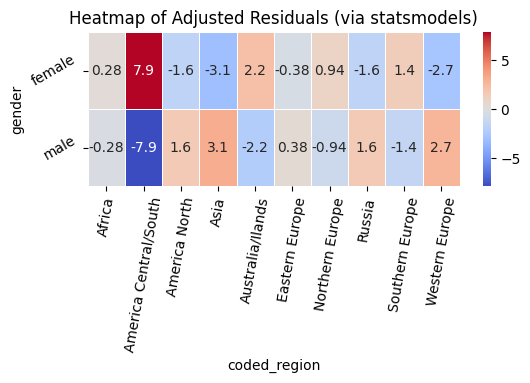

In [52]:
import statsmodels.api as sm

# 1. Create the Table object directly from your data
table = sm.stats.Table(X)

# 2. Get Adjusted Residuals instantly (no manual formula needed)
adjusted_resids = table.standardized_resids
# 3. Plot
fig, ax = plt.subplots(figsize=(6,2))         
# Sample figsize in inches
ax = sns.heatmap(adjusted_resids, annot=adjusted_resids, cmap="coolwarm", linewidths=.5, ax=ax)
labels = adjusted_resids.index
p = ax.set_yticklabels(labels, rotation=30)
labels_cols = adjusted_resids.columns
p = ax.set_xticklabels(labels_cols, rotation=80)

ax.set_title("Heatmap of Adjusted Residuals (via statsmodels)")
plt.show()

Grâce à ce tableau des températures nous pouvons néanmoins constater que les femmes occupent une place significativement plus que les hommes dans le champ de la sociologie en Amérique centrale et du Sud.

# Analyse bivariée des genres, des régions de naissance et des générations

In [53]:
## filter to only retain statistically significant categories, 
# given the obeserved distribution
df_pg = df_p[df_p['gender'].isin(['female', 'male'])]
df_pg.head(2)

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,FID,REGION,coded_region,activityYear,per_25
0,http://www.wikidata.org/entity/Q1685927,Jean-Guillaume-César-Alexandre-Hippolyte Colins,1783,male,Brussels metropolitan area,POINT (4.3525 50.846667),http://www.wikidata.org/entity/Q9005,1781-1790,22,Western Europe,Western Europe,1828,1828-1852
1,http://www.wikidata.org/entity/Q20012,Adolphe Quetelet,1796,male,Ghent,POINT (3.725278 51.053611),http://www.wikidata.org/entity/Q1296,1791-1800,22,Western Europe,Western Europe,1841,1828-1852


In [54]:
def code_gender_period(gender: str):
    if gender == 'female':
        output='f'
    else:
        output='m'
    return output  

In [55]:
df_pg['per_gender']= df_pg.apply(lambda x: x.per_25 +'_'+ code_gender_period(x.gender), axis=1)
df_pg.head(2)

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,FID,REGION,coded_region,activityYear,per_25,per_gender
0,http://www.wikidata.org/entity/Q1685927,Jean-Guillaume-César-Alexandre-Hippolyte Colins,1783,male,Brussels metropolitan area,POINT (4.3525 50.846667),http://www.wikidata.org/entity/Q9005,1781-1790,22,Western Europe,Western Europe,1828,1828-1852,1828-1852_m
1,http://www.wikidata.org/entity/Q20012,Adolphe Quetelet,1796,male,Ghent,POINT (3.725278 51.053611),http://www.wikidata.org/entity/Q1296,1791-1800,22,Western Europe,Western Europe,1841,1828-1852,1828-1852_m


In [56]:
per_gender_vs_region=pd.crosstab(df_pg.per_gender, df_pg.coded_region, margins=True)
per_gender_vs_region

coded_region,Africa,America Central/South,America North,Asia,Australia/Ilands,Eastern Europe,Northern Europe,Russia,Southern Europe,Western Europe,All
per_gender,,,,,,,,,,,
1828-1852_f,0,0,0,0,0,0,1,0,0,0,1
1828-1852_m,0,1,2,0,0,1,0,1,1,10,16
1853-1877_f,0,0,0,0,0,0,0,0,1,1,2
1853-1877_m,0,1,3,0,0,5,7,7,4,23,50
1878-1902_f,1,0,1,0,0,1,0,1,0,0,4
1878-1902_m,0,12,11,2,0,27,8,11,26,47,144
1903-1927_f,0,0,15,1,0,3,4,1,1,10,35
1903-1927_m,1,17,54,10,1,91,21,4,45,94,338
1928-1952_f,1,9,23,1,1,9,5,1,3,25,78


In [57]:
### All the period but with less regions
# X_reg_all_period = per_vs_region.loc[:, per_vs_region.iloc[-1] > 500].iloc[:-1, :-1 ]
X = per_gender_vs_region.iloc[:-1, :-1 ]

In [58]:
### Calcul des paramètres pour le test du Chi-2
statistic, p, dof, expected = stats.chi2_contingency(X)

In [60]:
### For significant chi-2 test minimal number in each cell of expected:5
# bias in the results
dfe = pd.DataFrame(expected).round(1)
dfe.index = X.index
dfe.columns = X.columns
dfe

coded_region,Africa,America Central/South,America North,Asia,Australia/Ilands,Eastern Europe,Northern Europe,Russia,Southern Europe,Western Europe
per_gender,,,,,,,,,,
1828-1852_f,0.0,0.1,0.1,0.1,0.0,0.2,0.1,0.0,0.1,0.3
1828-1852_m,0.4,1.3,1.6,1.4,0.1,3.1,0.8,0.5,2.2,4.6
1853-1877_f,0.0,0.2,0.2,0.2,0.0,0.4,0.1,0.1,0.3,0.6
1853-1877_m,1.1,4.2,5.2,4.4,0.2,9.5,2.5,1.7,6.7,14.5
1878-1902_f,0.1,0.3,0.4,0.3,0.0,0.8,0.2,0.1,0.5,1.2
1878-1902_m,3.2,12.1,14.8,12.6,0.6,27.5,7.2,4.8,19.4,41.8
1903-1927_f,0.8,2.9,3.6,3.1,0.2,6.7,1.8,1.2,4.7,10.2
1903-1927_m,7.4,28.3,34.8,29.5,1.5,64.4,17.0,11.3,45.6,98.1
1928-1952_f,1.7,6.5,8.0,6.8,0.3,14.9,3.9,2.6,10.5,22.6


In [61]:
print('Chi2 :', statistic, ', dof :',dof)
print('p-value :', p)

Chi2 : 866.2451521900839 , dof : 153
p-value : 5.128605807097078e-100


Le test de chi-2 n'est toujours pas significatif et nous ne pouvons pas rejeter H0, c'est à dire l'indépendance des variables.

In [62]:
### Cramér's phi coefficient
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.contingency.association.html
vc = stats.contingency.association(X, method='cramer')
print('Cramèr\'s V:', vc)

Cramèr's V: 0.0988008535218108


Toujours aucune nouvelle information apportée par le V de Cramèr.

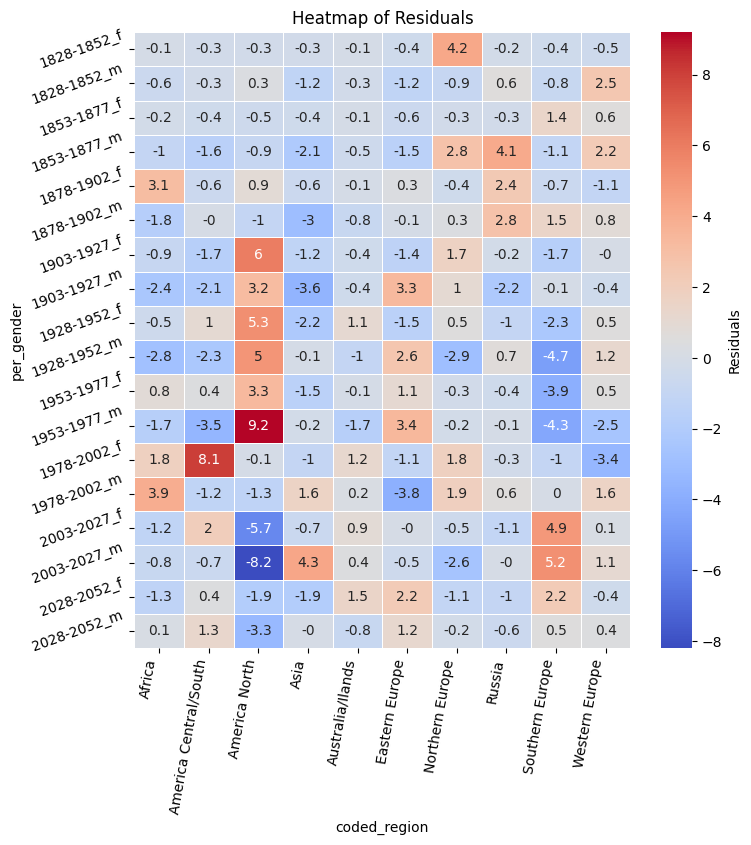

In [64]:
# 3. Plot
fig, ax = plt.subplots(figsize=(8,8))         

# Create heatmap
sns.heatmap(
    std_res, 
    annot=True,            # Use boolean True to annotate with data values
    cmap="coolwarm", 
    linewidths=.5, 
    ax=ax,
    cbar_kws={'label': 'Residuals'}
)
# 3. Fix Label Rotation (Safe Method)
# This rotates existing ticks without risking a count mismatch
ax.set_xticklabels(ax.get_xticklabels(), rotation=80, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=20, va='center')

ax.set_title("Heatmap of Residuals")
plt.show()

Malgré tout, nous pouvons retrouver quelques tendances sur ce tableau des températures. Entre 1953 et 1977 les hommes occupent une place forte dans le domaine de la sociologie en Amérique du Nord, place qu'ils perdent entre 2003 et 2027. Entre 1978 et 2002 se sont les femmes d'Amérique centrale et du Sud cette fois-ci qui se distinguent nettement.

# Solution possible : restreindre la table aux données plus récentes

In [66]:
per_gender_vs_region=pd.crosstab(df_pg.per_gender, df_pg.coded_region, margins=True).iloc[8:, :]
per_gender_vs_region

coded_region,Africa,America Central/South,America North,Asia,Australia/Ilands,Eastern Europe,Northern Europe,Russia,Southern Europe,Western Europe,All
per_gender,,,,,,,,,,,
1928-1952_f,1,9,23,1,1,9,5,1,3,25,78
1928-1952_m,3,33,100,51,1,140,14,23,38,187,590
1953-1977_f,7,22,41,14,1,53,11,7,10,74,240
1953-1977_m,21,78,252,118,2,318,68,46,128,351,1382
1978-2002_f,30,156,100,77,7,172,62,31,121,227,983
1978-2002_m,103,248,306,306,15,518,185,114,432,977,3204
2003-2027_f,15,95,40,75,6,176,43,25,180,271,926
2003-2027_m,30,124,58,188,8,293,56,53,288,481,1579
2028-2052_f,1,15,9,7,2,43,5,3,32,44,161


In [67]:
### All the period but with less regions
# X_reg_all_period = per_vs_region.loc[:, per_vs_region.iloc[-1] > 500].iloc[:-1, :-1 ]
X = per_gender_vs_region.iloc[:-1, :-1 ]

In [68]:
### Calcul des paramètres pour le test du Chi-2
statistic, p, dof, expected = stats.chi2_contingency(X)

In [70]:
### For significant chi-2 test minimal number in each cell of expected:5
# bias in the results
dfe = pd.DataFrame(expected).round(1)
dfe.index = X.index
dfe.columns = X.columns
dfe

coded_region,Africa,America Central/South,America North,Asia,Australia/Ilands,Eastern Europe,Northern Europe,Russia,Southern Europe,Western Europe
per_gender,,,,,,,,,,
1928-1952_f,1.8,6.7,7.8,7.1,0.4,14.7,3.8,2.6,10.5,22.5
1928-1952_m,13.6,50.6,59.2,54.0,2.7,111.5,29.0,19.5,79.6,170.3
1953-1977_f,5.5,20.6,24.1,22.0,1.1,45.4,11.8,7.9,32.4,69.3
1953-1977_m,31.9,118.5,138.6,126.4,6.4,261.2,67.8,45.6,186.5,398.9
1978-2002_f,22.7,84.3,98.6,89.9,4.6,185.8,48.2,32.4,132.7,283.8
1978-2002_m,74.0,274.8,321.4,293.1,14.9,605.5,157.3,105.8,432.4,924.9
2003-2027_f,21.4,79.4,92.9,84.7,4.3,175.0,45.5,30.6,125.0,267.3
2003-2027_m,36.5,135.4,158.4,144.4,7.3,298.4,77.5,52.1,213.1,455.8
2028-2052_f,3.7,13.8,16.2,14.7,0.7,30.4,7.9,5.3,21.7,46.5


In [71]:
print('Chi2 :', statistic, ', dof :',dof)
print('p-value :', p)

Chi2 : 646.1379609775281 , dof : 81
p-value : 5.718133965253131e-89


Malgré la tentative de restriction des données, le test du chi-2 n'est toujours pas significatif, nous ne pouvons donc pas rejeter H0.

In [72]:
### Cramér's phi coefficient
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.contingency.association.html
vc = stats.contingency.association(X, method='cramer')
print('Cramèr\'s V:', vc)

Cramèr's V: 0.08800381646578623


Idem aux autres V de Cramèr.

In [73]:
### Standaradized chi-2 contribution
# Basic formula
std_res = (round((X-expected)/np.sqrt(expected),1))
# std_res.head(2)

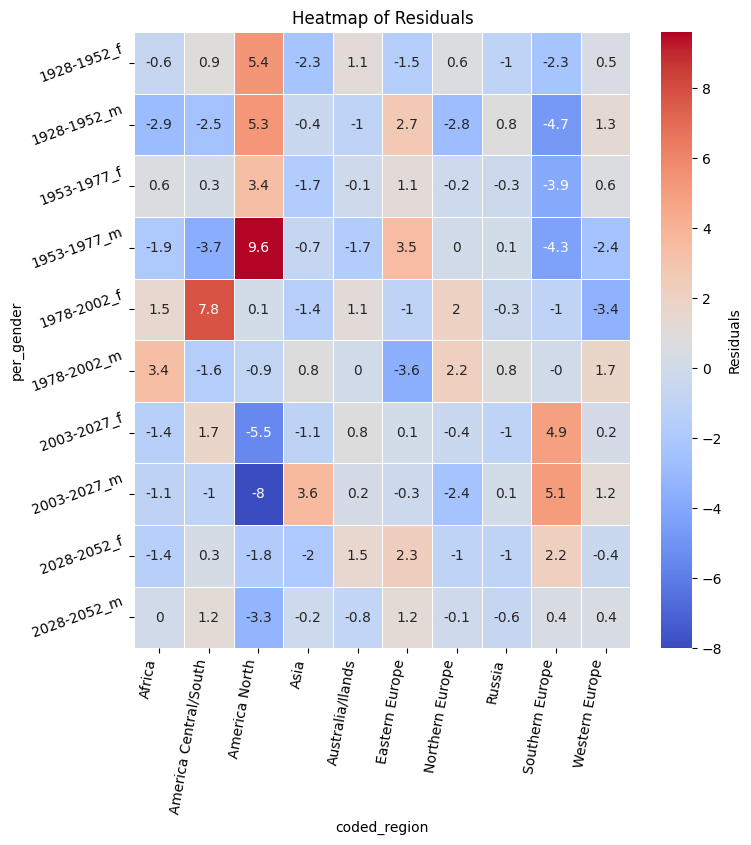

In [74]:
# 3. Plot
fig, ax = plt.subplots(figsize=(8,8))         

# Create heatmap
sns.heatmap(
    std_res, 
    annot=True,            # Use boolean True to annotate with data values
    cmap="coolwarm", 
    linewidths=.5, 
    ax=ax,
    cbar_kws={'label': 'Residuals'}
)
# 3. Fix Label Rotation (Safe Method)
# This rotates existing ticks without risking a count mismatch
ax.set_xticklabels(ax.get_xticklabels(), rotation=80, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=20, va='center')

ax.set_title("Heatmap of Residuals")
plt.show()

Ce nouveau tableau des températures ne nous apprend qui de plus que le précédent et ne fait qu'en confirmer les tendances.

In [75]:
df_pg.head()

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,FID,REGION,coded_region,activityYear,per_25,per_gender
0,http://www.wikidata.org/entity/Q1685927,Jean-Guillaume-César-Alexandre-Hippolyte Colins,1783,male,Brussels metropolitan area,POINT (4.3525 50.846667),http://www.wikidata.org/entity/Q9005,1781-1790,22,Western Europe,Western Europe,1828,1828-1852,1828-1852_m
1,http://www.wikidata.org/entity/Q20012,Adolphe Quetelet,1796,male,Ghent,POINT (3.725278 51.053611),http://www.wikidata.org/entity/Q1296,1791-1800,22,Western Europe,Western Europe,1841,1828-1852,1828-1852_m
2,http://www.wikidata.org/entity/Q1708975,José Antonio Saco,1797,male,Bayamo,POINT (-76.642778 20.381667),http://www.wikidata.org/entity/Q115382,1791-1800,3,Caribbean,America Central/South,1842,1828-1852,1828-1852_m
3,http://www.wikidata.org/entity/Q973094,Ramón de la Sagra,1798,male,A Coruña,POINT (-8.400027 43.373857),http://www.wikidata.org/entity/Q8757,1791-1800,19,Southern Europe,Southern Europe,1843,1828-1852,1828-1852_m
4,http://www.wikidata.org/entity/Q957065,Henry Charles Carey,1793,male,Philadelphia,POINT (-75.163611 39.952778),http://www.wikidata.org/entity/Q1345,1791-1800,23,Northern America,America North,1838,1828-1852,1828-1852_m
